In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("realistic_e_commerce_sales_data.csv")
print(df.head())

  Customer ID  Gender Region  ...  Shipping Fee Shipping Status  Order Date
0    CUST0268    Male  North  ...         13.31        Returned  2023-12-08
1    CUST0046    Male   West  ...          6.93      In Transit  2023-04-09
2    CUST0169  Female  South  ...         11.31        Returned  2023-08-28
3    CUST0002    Male  North  ...         12.22       Delivered  2023-01-18
4    CUST0173  Female  South  ...          5.40       Delivered  2023-01-19

[5 rows x 12 columns]


In [5]:
print("Rows: ",df.shape[0])
print("Column: ",df.shape[1])

Rows:  1000
Column:  12


In [7]:
columns = pd.DataFrame(df.columns,columns=["columns"])
display(columns)

,columns
0,Customer ID
1,Gender
2,Region
3,Age
4,Product Name
5,Category
6,Unit Price
7,Quantity
8,Total Price
9,Shipping Fee


In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"])


In [9]:
df.isnull().sum()

Customer ID          0
Gender               0
Region              50
Age                100
Product Name         0
Category             0
Unit Price           0
Quantity             0
Total Price          0
Shipping Fee         0
Shipping Status     50
Order Date           0
dtype: int64

In [10]:
df.isnull().sum().sum()

np.int64(200)

In [4]:
df["Age"]= df["Age"].fillna(df["Age"].median())

In [6]:
df["Region"]= df["Region"].fillna("Unknown")

In [7]:
df["Shipping Status"] = df["Shipping Status"].fillna("Unknown")

In [8]:
print(df.isnull().sum().sum())

0


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,Age,Unit Price,Quantity,Total Price,Shipping Fee
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,46.926000,457.703777,3.008000,1346.600000,12.416390
std,14.257061,537.231434,1.404246,1834.037877,4.412185
min,18.000000,30.000000,1.000000,30.000000,5.000000
25%,37.000000,50.000000,2.000000,200.000000,8.560000
50%,49.000000,200.000000,3.000000,600.000000,12.315000
75%,58.000000,800.000000,4.000000,1500.000000,16.075000
max,69.000000,3109.560612,5.000000,7500.000000,19.980000


In [15]:
total_revenue = df["Total Price"].sum()
print(total_revenue)

1346600


In [18]:
total_orders = df.shape[0]

print("Total Orders:", total_orders)

Total Orders: 1000


In [17]:
total_quantity = df["Quantity"].sum()
print(total_quantity)

3008


In [21]:
aov = df["Total Price"].mean()
print( aov)

1346.6


In [24]:
df["Revenue"] = df["Total Price"]


In [23]:
df["Revenue_With_Shipping"] = (
    df["Total Price"] + df["Shipping Fee"]
)

In [26]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Month"] = df["Order Date"].dt.to_period("M")

In [27]:
monthly_revenue = (
    df.groupby("Month")["Total Price"]
      .sum()
)

print(monthly_revenue)

Month
2023-01    141360
2023-02     78910
2023-03     67660
2023-04     87840
2023-05    120080
2023-06    129450
2023-07    103160
2023-08    108050
2023-09    119490
2023-10    118240
2023-11    147150
2023-12    113830
2024-01     11380
Freq: M, Name: Total Price, dtype: int64


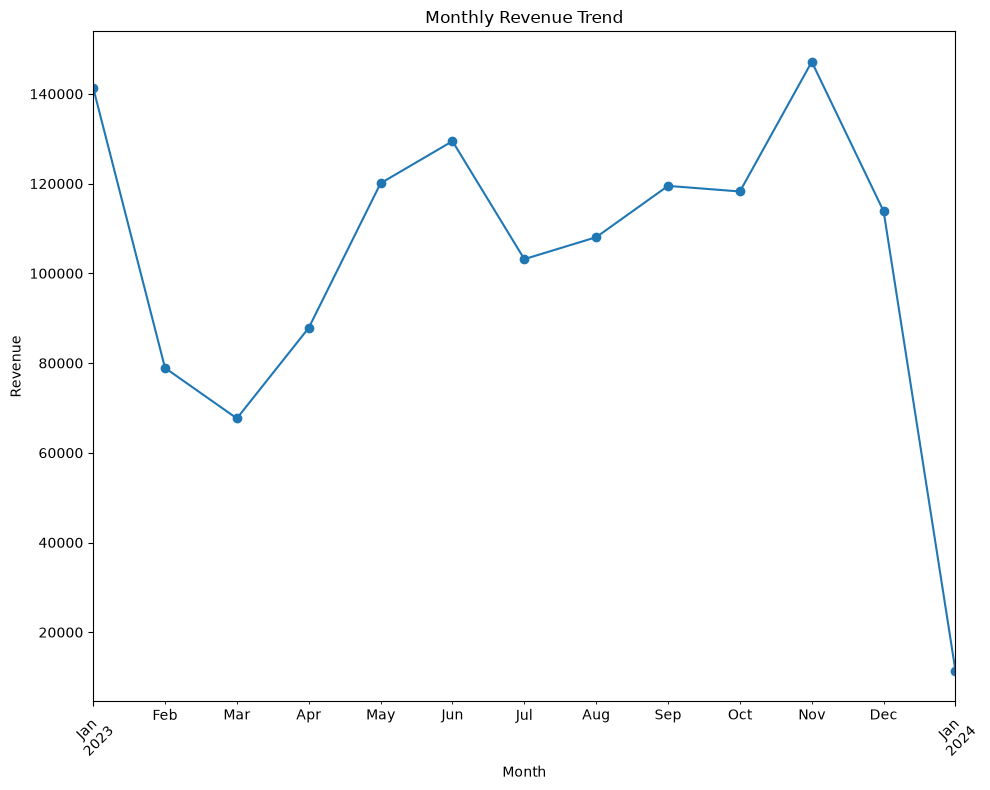

In [29]:
monthly_revenue.plot(figsize=(10,8), marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [31]:
category_sales = df.groupby("Category")["Total Price"].sum().sort_values(ascending=False)
print(category_sales)

Category
Electronics    1200500
Wearables        74200
Accessories      71900
Name: Total Price, dtype: int64


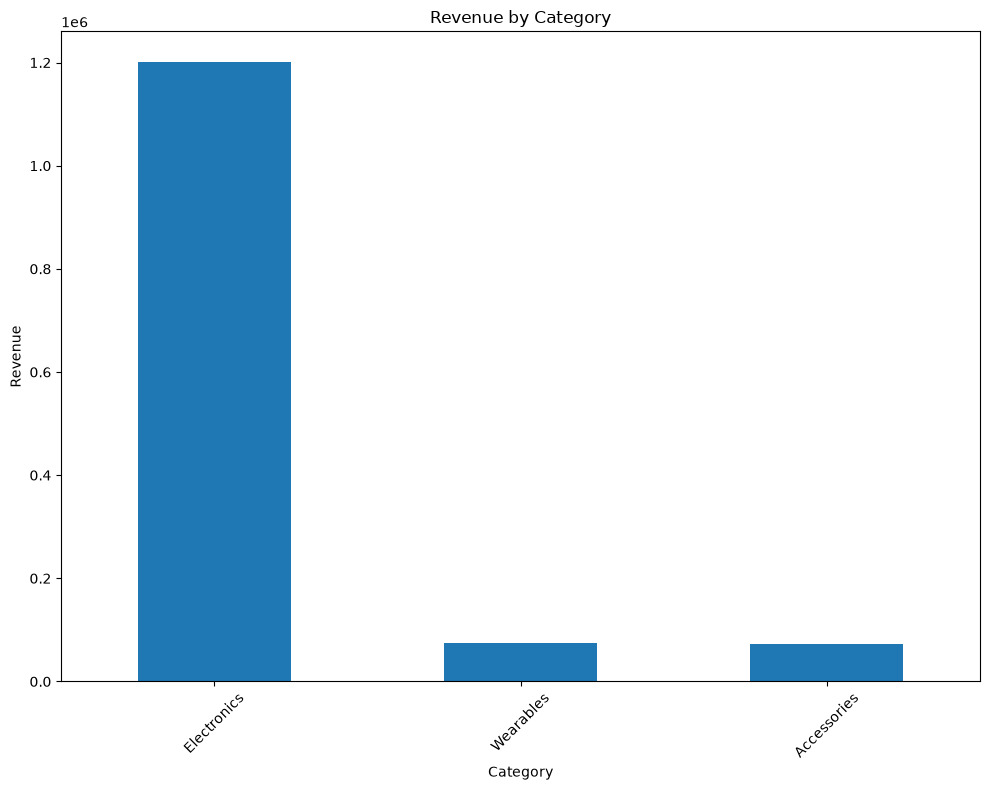

In [33]:
category_sales.plot(kind="bar",figsize=(10,8))
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [3]:
product_sales = (df.groupby("Product Name")["Total Price"].sum().sort_values(ascending=False).head(10))
print(product_sales)  

Product Name
Laptop        696000
Smartphone    353600
Monitor       150900
Smartwatch     74200
Headphones     37000
Keyboard       22900
Mouse          12000
Name: Total Price, dtype: int64


In [4]:
regional_sale = df.groupby("Region")["Total Price"].sum().sort_values(ascending=False)
print(regional_sale)

Region
East     329950
North    324990
West     323390
South    301040
Name: Total Price, dtype: int64


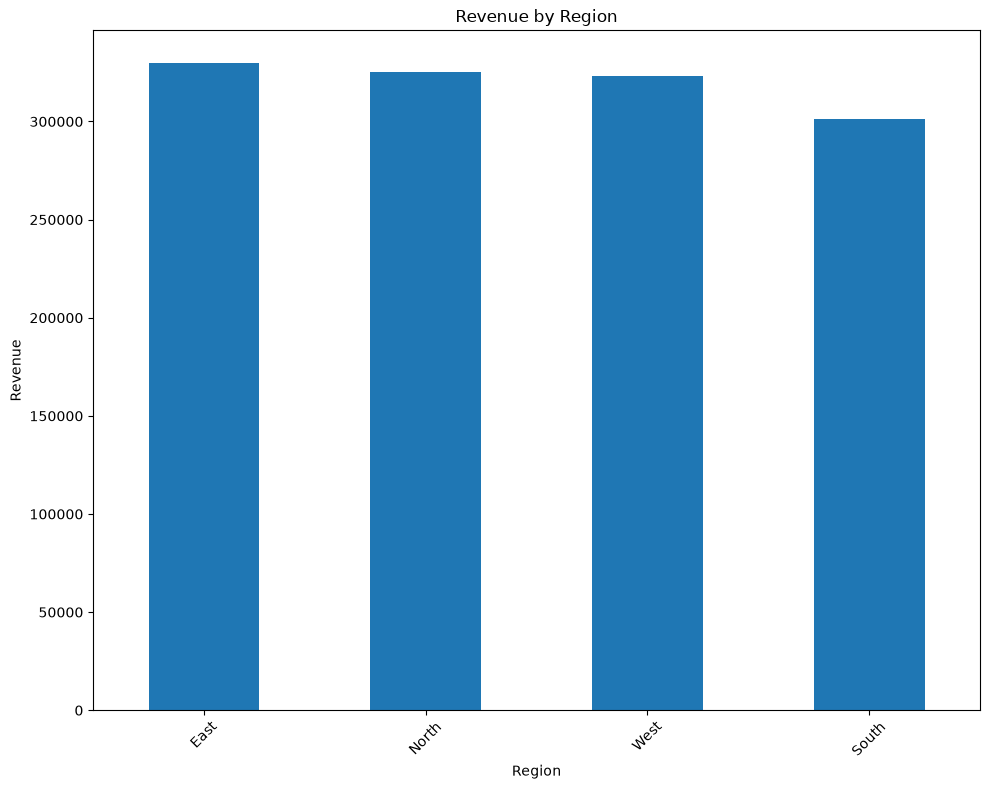

In [5]:
regional_sale.plot(kind="bar", figsize=(10, 8))
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
customer_sales =(df.groupby("Customer ID")["Total Price"].sum().sort_values(ascending=False).head(10))
print(customer_sales)

Customer ID
CUST0204    29100
CUST0095    22440
CUST0131    21180
CUST0139    18350
CUST0281    17850
CUST0144    17320
CUST0200    16700
CUST0197    16150
CUST0064    14600
CUST0293    14200
Name: Total Price, dtype: int64


In [5]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [6]:
analysis_date = df["Order Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg(
    Recency=("Order Date", 
             lambda x: (analysis_date - x.max()).days),

    Frequency=("Order Date", "count"),

    Monetary=("Total Price", "sum")
)

print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
CUST0001         253          2      6150
CUST0002         116          3      1550
CUST0003          59          3      4890
CUST0004           1          5      6500
CUST0005         323          1        60


In [10]:
analysis_date = df["Order Date"].max()+pd.Timedelta(days=1)
rfm = df.groupby("Customer ID").agg(
    Recency= ("Order Date",lambda x: (analysis_date - x.max()).days),
    Frequency=("Order Date", "count"),
    Monetary=("Total Price", "sum")
)
print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
CUST0001         253          2      6150
CUST0002         116          3      1550
CUST0003          59          3      4890
CUST0004           1          5      6500
CUST0005         323          1        60


In [11]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

In [16]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int) +
    rfm["F_Score"].astype(int) +
    rfm["M_Score"].astype(int)
)
print(rfm.head())

             Recency  Frequency  Monetary R_Score F_Score M_Score  RFM_Score
Customer ID                                                                 
CUST0001         253          2      6150       1       1       4          6
CUST0002         116          3      1550       2       2       2          6
CUST0003          59          3      4890       3       2       3          8
CUST0004           1          5      6500       5       4       4         13
CUST0005         323          1        60       1       1       1          3


In [4]:
customer_sales = (
    df.groupby("Customer ID")["Total Price"]
      .sum()
      .sort_values(ascending=False)
)

customer_sales_pct = (
    customer_sales.cumsum() /
    customer_sales.sum()
) * 100

print(customer_sales_pct.head(20))

Customer ID
CUST0204     2.160998
CUST0095     3.827417
CUST0131     5.400267
CUST0139     6.762959
CUST0281     8.088519
CUST0144     9.374722
CUST0200    10.614882
CUST0197    11.814199
CUST0064    12.898411
CUST0293    13.952918
CUST0160    14.974009
CUST0129    15.973563
CUST0031    16.924105
CUST0203    17.850884
CUST0176    18.771721
CUST0138    19.688846
CUST0156    20.579979
CUST0106    21.407990
CUST0133    22.232289
CUST0178    23.056587
Name: Total Price, dtype: float64


In [5]:
numeric_cols = [
    "Age",
    "Unit Price",
    "Quantity",
    "Total Price",
    "Shipping Fee"
]

corr = df[numeric_cols].corr()

print(corr)

                   Age  Unit Price  Quantity  Total Price  Shipping Fee
Age           1.000000    0.056832  0.014651     0.038775      0.027020
Unit Price    0.056832    1.000000  0.002678     0.824360      0.016851
Quantity      0.014651    0.002678  1.000000     0.360877      0.045812
Total Price   0.038775    0.824360  0.360877     1.000000      0.003249
Shipping Fee  0.027020    0.016851  0.045812     0.003249      1.000000


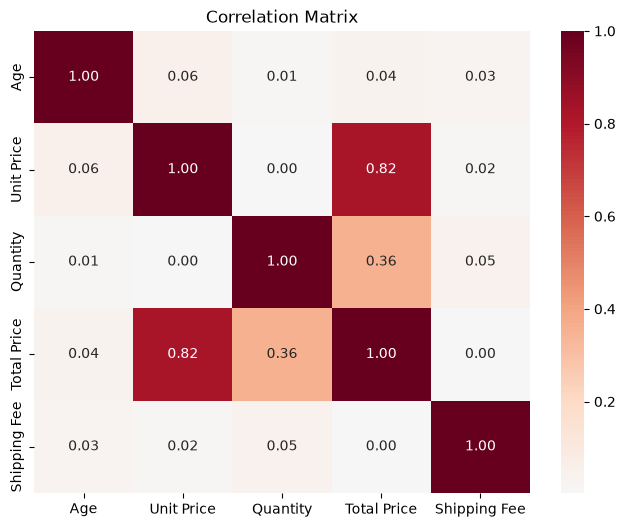

In [6]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [5]:
from scipy.stats import ttest_ind

male = df[
    df["Gender"] == "Male"
]["Total Price"]

female = df[
    df["Gender"] == "Female"
]["Total Price"]

t_stat, p_value = ttest_ind(
    male,
    female,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.3440899589878226
P-value: 0.7308518057158803


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[
    ["Unit Price", "Quantity", "Shipping Fee", "Age"]
]
X = X.fillna(X.median())
y = df["Total Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error ,r2_score

mea = mean_absolute_error(y_test,predictions)
r2 = r2_score(y_test,predictions)
print("MEA:",mea)
print("r2:",r2)

MEA: 595.0493406504111
r2: 0.8300980519750177


In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
features = rfm[["Recency","Frequency","Monetary"]]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
kmeans =KMeans(n_clusters = 4,random_state =42,n_init=10)
rfm["Cluster"]= kmeans.fit_predict(scaled_features)
print(
    rfm.groupby("Cluster")[
        ["Recency", "Frequency", "Monetary"]
    ].mean()
)

            Recency  Frequency      Monetary
Cluster                                     
0        239.807692   1.807692   1910.000000
1         47.510000   4.950000   6484.100000
2         70.362903   2.491935   2701.532258
3         49.562500   6.375000  16492.500000


In [8]:
monthly = (
    df.groupby(
        df["Order Date"].dt.to_period("M")
    )["Total Price"]
    .sum()
)

monthly = monthly.to_timestamp()

In [9]:
monthly_ma = monthly.rolling(
    window=3
).mean()

print(monthly_ma)

Order Date
2023-01-01              NaN
2023-02-01              NaN
2023-03-01     95976.666667
2023-04-01     78136.666667
2023-05-01     91860.000000
2023-06-01    112456.666667
2023-07-01    117563.333333
2023-08-01    113553.333333
2023-09-01    110233.333333
2023-10-01    115260.000000
2023-11-01    128293.333333
2023-12-01    126406.666667
2024-01-01     90786.666667
Freq: MS, Name: Total Price, dtype: float64


In [10]:
from sklearn.ensemble import IsolationForest

features = df[
    ["Quantity", "Unit Price", "Total Price", "Shipping Fee"]
]

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

df["Anomaly"] = model.fit_predict(features)

print(
    df[df["Anomaly"] == -1]
)

    Customer ID  Gender Region  ...  Shipping Status Order Date Anomaly
4      CUST0173  Female  South  ...        Delivered 2023-01-19      -1
57     CUST0207    Male  South  ...        Delivered 2023-03-14      -1
59     CUST0006    Male  South  ...       In Transit 2023-09-17      -1
71     CUST0261    Male   West  ...         Returned 2023-10-01      -1
79     CUST0269  Female   East  ...         Returned 2023-12-03      -1
113    CUST0289    Male   West  ...        Delivered 2023-07-06      -1
127    CUST0078  Female  North  ...       In Transit 2023-05-10      -1
130    CUST0212  Female  North  ...       In Transit 2023-11-18      -1
205    CUST0095  Female   East  ...         Returned 2023-06-18      -1
237    CUST0272  Female   West  ...              NaN 2023-05-13      -1
293    CUST0204  Female  South  ...         Returned 2023-08-28      -1
300    CUST0106    Male  North  ...       In Transit 2023-06-08      -1
322    CUST0281    Male   West  ...        Delivered 2023-11-21 